In [ ]:
import os
import seaborn as sns
import s3fs
from dotenv import load_dotenv
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt

In [4]:

#load the environment variables from the .env file
load_dotenv(override=True)

#load the dataset stored in the s3 bucket of MinIO
fs=s3fs.S3FileSystem(key=os.getenv("AWS_ACCESS_KEY_ID"), 
                  secret=os.getenv("AWS_SECRET_ACCESS_KEY"),
                  token=os.getenv("AWS_SESSION_TOKEN"),
                  client_kwargs={'endpoint_url':  'https://'+ os.getenv("AWS_S3_ENDPOINT")})


#load the train dataset
train_path= os.getenv("AWS_BUCKET_NAME") + '/train.csv'
with fs.open(train_path, mode='rb') as f:
        df = pd.read_csv(f)

In [5]:
df.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [28]:
df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [29]:
df[df.select_dtypes(include='str').columns].nunique()

person_home_ownership        4
loan_intent                  6
loan_grade                   7
cb_person_default_on_file    2
dtype: int64

In [30]:
for column in df.select_dtypes(include='str').columns:
    print(f"Unique values in column {column}: {list(df[column].unique())}")

Unique values in column person_home_ownership: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Unique values in column loan_intent: ['EDUCATION', 'MEDICAL', 'PERSONAL', 'VENTURE', 'DEBTCONSOLIDATION', 'HOMEIMPROVEMENT']
Unique values in column loan_grade: ['B', 'C', 'A', 'D', 'E', 'F', 'G']
Unique values in column cb_person_default_on_file: ['N', 'Y']


# Features description
* **`id`**: Unique identifier for each loan application (integer from 0 to 58644)

* **`person_age`**: Age of the loan applicant in years

* **`person_income`**: Annual income of the applicant

* **`person_home_ownership`**: Home ownership status of the applicant (rent, own, mortgage, other)

* **`person_emp_length`**: Number of years the applicant has been employed

* **`loan_intent`**: Purpose of the loan (education, medical, personal, home improvement, venture, debt consolidation)

* **`loan_amnt`**: Total amount of money requested for the loan

* **`loan_percent_income`**: Ratio of the loan amount to the applicant's annual income

* **`cb_person_default_on_file`**: Indicates whether the applicant has a previous record of credit default (`Y` or `N`)

* **`cb_person_cred_hist_length`**: Length of the applicant's credit history in years


Those variables could provoke a data leakage : 

* **`loan_grade`**: Risk grade assigned to the loan based on the applicant's creditworthiness

* **`loan_int_rate`**: Interest rate assigned to the loan

The target variable:

* **`loan_status`**: Target variable indicating whether the loan was approved or rejected (0 or 1)

loan_status
0    85.761787
1    14.238213
Name: count, dtype: float64


<Axes: >

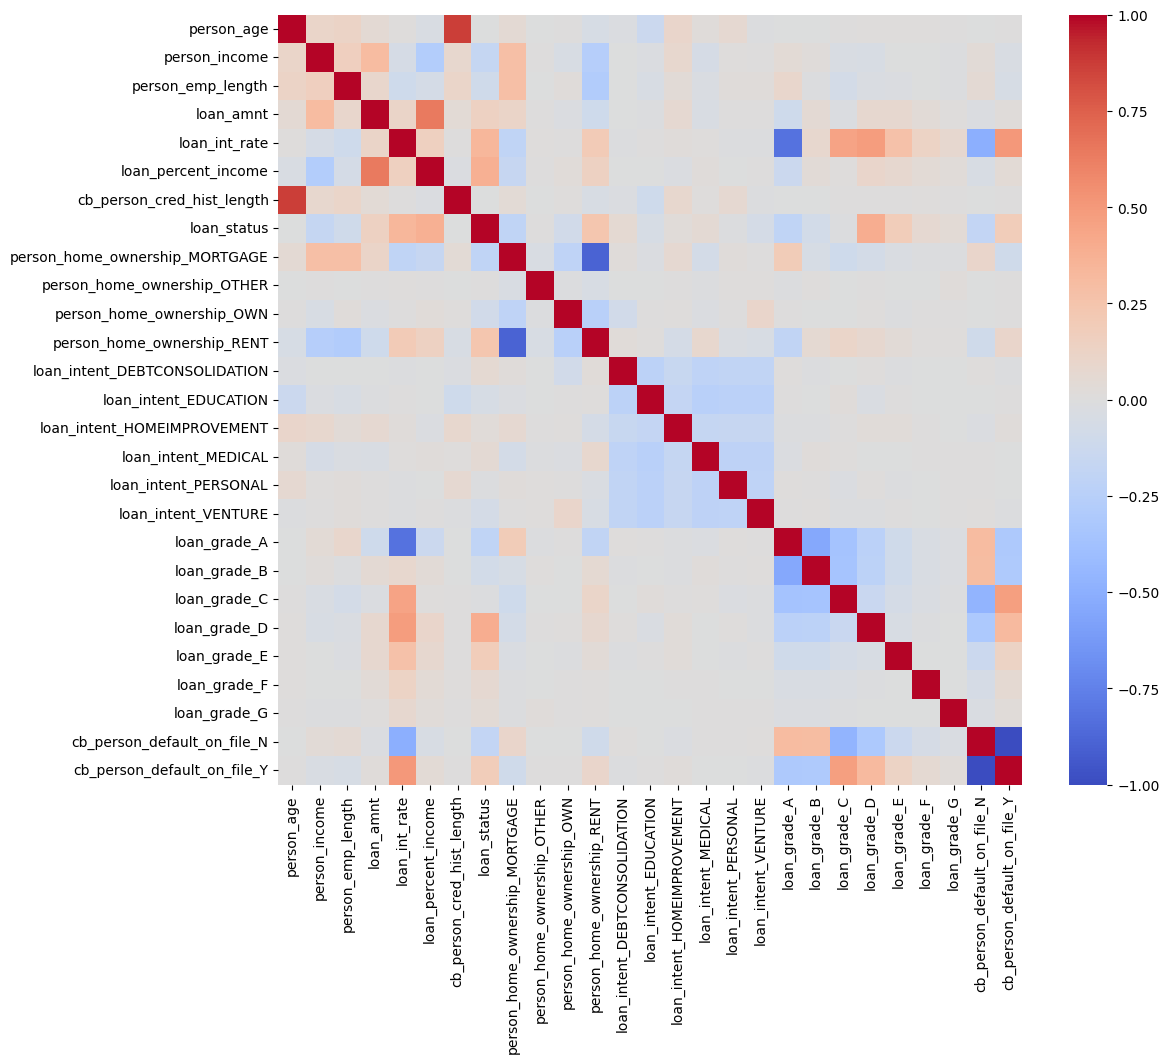

In [31]:
# Exploratory analysis

#drop index column
df.drop(columns=["id"], inplace=True)

print(df["loan_status"].value_counts()/len(df)*100) #train sample with imbalanced classes

#convert the str columns to dummy variables (one-hot encoding)
df = pd.get_dummies(df, columns=df.select_dtypes(include='str').columns, dtype=int)

plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), cmap="coolwarm") 

# Modelisation

In [ ]:
#Split train and validation sets
X_train, X_val, y_train, y_val= train_test_split(df.drop(columns=["loan_status"]), df["loan_status"], test_size=0.2, random_state=42)

In [33]:

rf=RandomForestClassifier(n_estimators=100, criterion="gini", oob_score=True, random_state=42)
rf.fit(X_train, y_train)

#metrics: f1 and recall (more relevant metrics for imbalanced datasets)
print("F1 Score:", metrics.f1_score(y_val, rf.predict(X_val))) #poor f1 (imbalanced dataset)
print("Recall Score:", metrics.recall_score(y_val, rf.predict(X_val))) #especially poor recall (many false negatives)

F1 Score: 0.8103506979911475
Recall Score: 0.7247259439707674


In [34]:
#random forest with balanced option to handle class imbalance
rf=RandomForestClassifier(n_estimators=100, class_weight="balanced", criterion="gini", oob_score=True, random_state=42)
rf.fit(X_train, y_train)
rf.score(X_val, y_val)
print("F1 Score:", metrics.f1_score(y_val, rf.predict(X_val))) #poor f1 (imbalanced dataset)
print("Recall Score:", metrics.recall_score(y_val, rf.predict(X_val)))

#...worse

F1 Score: 0.8079561042524005
Recall Score: 0.7174177831912302


In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

scale = (58000 * 0.86) / (58000 * 0.14)  # ≈ 6.1
xgb = XGBClassifier(scale_pos_weight=scale, random_state=42)

# LightGBM
lgbm = LGBMClassifier(is_unbalance=True, random_state=42)

ImportError: cannot import name 'LGBMClassifier' from 'xgboost' (/Users/wiamlachqer/Library/Mobile Documents/com~apple~CloudDocs/Mise en prod/Loan-prediction-approval/.venv/lib/python3.13/site-packages/xgboost/__init__.py)